# PrintBid Price Prediction Model

This notebook uses the final `price_dataset.csv` dataset for the PrintBid final-year project.

The dataset contains **1,000 printing quotation records**. The target variable is `total_price`.

The notebook includes **8 Exploratory Data Analysis (EDA) checks** before model training.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

DATASET_PATH = "../datasets/price_dataset.csv"

price_dataset = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully")
print("Dataset shape:", price_dataset.shape)
print("Total records:", len(price_dataset))
print("Total columns:", len(price_dataset.columns))

display(price_dataset.head())

Dataset loaded successfully
Dataset shape: (1000, 23)
Total records: 1000
Total columns: 23


,quotation_id,quotation_date,print_category,quantity,standard_size,width,height,paper_type,gsm,colour_mode,...,urgency,delivery_requirement,printing_cost,finishing_cost,delivery_cost,total_price,location,data_source,access_date,data_type
0,PUB-0001,2026-08-20,business cards,100,NaN,NaN,NaN,art paper,300.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1500.0,NaN,https://advertisingsrilanka.lk/business-card-p...,2026-08-20,Publicly available Sri Lankan price
1,PUB-0002,2026-08-20,business cards,200,NaN,NaN,NaN,art paper,300.0,NaN,...,NaN,NaN,NaN,NaN,NaN,3500.0,NaN,https://advertisingsrilanka.lk/business-card-p...,2026-08-20,Publicly available Sri Lankan price
2,PUB-0003,2026-08-06,business cards,500,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,15000.0,NaN,https://advertisingsrilanka.lk/business-card-p...,2026-08-20,Publicly available Sri Lankan price
3,PUB-0004,2026-08-09,business cards,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,12.0,NaN,https://printit.lk/product/business-cards-prin...,2026-08-20,Publicly available Sri Lankan price
4,PUB-0005,2026-08-12,business cards,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,26.5,NaN,https://printit.lk/product/business-cards-prin...,2026-08-20,Publicly available Sri Lankan price


## EDA 1 - Dataset Overview

In [2]:
print("Dataset shape:", price_dataset.shape)
print("\nColumn names:")
print(price_dataset.columns.tolist())

print("\nData types:")
display(price_dataset.dtypes.to_frame("Data Type"))

print("\nNumerical summary:")
display(price_dataset.describe().T)

Dataset shape: (1000, 23)

Column names:
['quotation_id', 'quotation_date', 'print_category', 'quantity', 'standard_size', 'width', 'height', 'paper_type', 'gsm', 'colour_mode', 'sides', 'page_count', 'finishing_type', 'urgency', 'delivery_requirement', 'printing_cost', 'finishing_cost', 'delivery_cost', 'total_price', 'location', 'data_source', 'access_date', 'data_type']

Data types:


,Data Type
quotation_id,str
quotation_date,str
print_category,str
quantity,int64
standard_size,str
width,float64
height,float64
paper_type,str
gsm,float64
colour_mode,str



Numerical summary:


,count,mean,std,min,25%,50%,75%,max
quantity,1000.0,1184.454000,8959.107289,1.0,5.000,20.00,200.0000,100000.0
width,20.0,4.550000,2.350252,2.0,2.750,4.00,6.0000,10.0
height,20.0,6.300000,3.147263,3.0,3.750,6.00,8.0000,15.0
gsm,834.0,132.074341,86.376374,80.0,80.000,80.00,230.0000,350.0
page_count,774.0,37.074935,73.602264,1.0,1.000,1.00,20.0000,300.0
printing_cost,988.0,41694.055294,262815.300332,0.0,22.365,1491.47,10027.6750,5000000.0
finishing_cost,988.0,1713.658431,6488.502478,0.0,0.000,0.00,626.8325,75000.0
delivery_cost,988.0,217.105263,257.719563,0.0,0.000,0.00,350.0000,650.0
total_price,1000.0,46150.947710,267067.979754,3.0,573.030,2642.47,12468.8825,5000000.0


## EDA 2 - Missing Values

,Missing Values,Percentage (%)
height,980,98.0
width,980,98.0
access_date,254,25.4
colour_mode,230,23.0
page_count,226,22.6
gsm,166,16.6
delivery_requirement,117,11.7
urgency,117,11.7
sides,113,11.3
standard_size,31,3.1


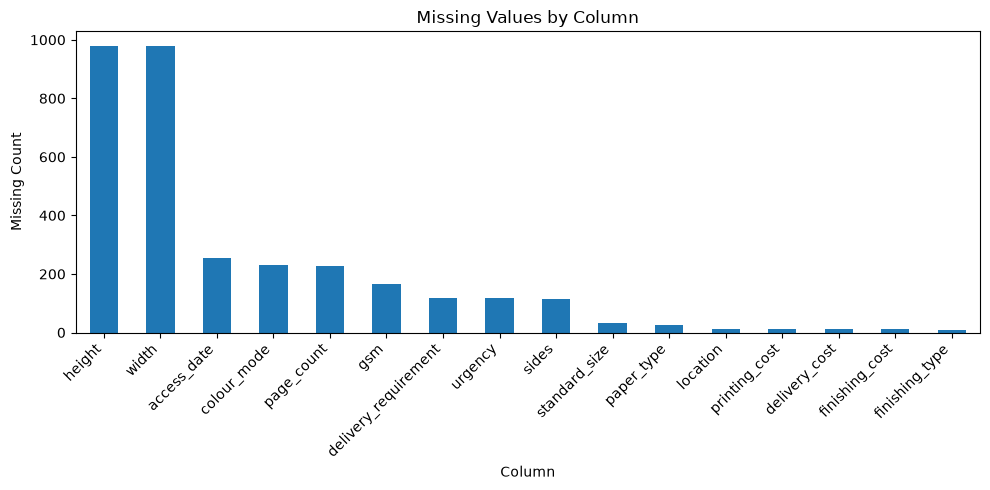

In [3]:
missing_values = price_dataset.isnull().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(price_dataset) * 100).round(2)
})
display(missing_table[missing_table["Missing Values"] > 0])

plt.figure(figsize=(10, 5))
missing_values[missing_values > 0].plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## EDA 3 - Duplicate Records

In [ ]:
feature_cols = [c for c in price_dataset.columns if c not in ["quotation_id", "quotation_date", "data_source", "access_date"]]
duplicate_count = price_dataset.duplicated(subset=feature_cols).sum()
print("Duplicate records:", duplicate_count)

if duplicate_count > 0:
    display(price_dataset[price_dataset.duplicated(subset=feature_cols)].head())
else:
    print("No complete duplicate rows were found.")

Duplicate records: 0
No complete duplicate rows were found.


## EDA 4 - Total Price Distribution

count    1.000000e+03
mean     4.615095e+04
std      2.670680e+05
min      3.000000e+00
25%      5.730300e+02
50%      2.642470e+03
75%      1.246888e+04
max      5.000000e+06
Name: total_price, dtype: float64


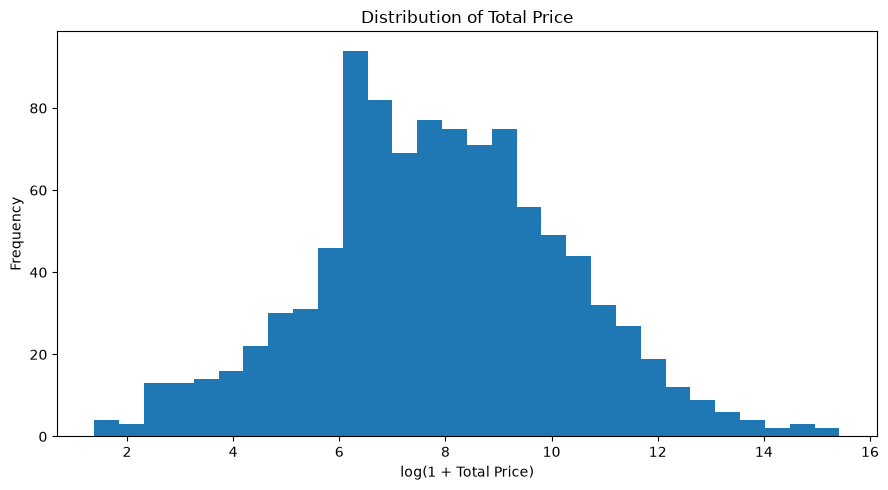

In [5]:
print(price_dataset["total_price"].describe())

plt.figure(figsize=(9, 5))
plt.hist(np.log1p(price_dataset["total_price"]), bins=30)
plt.title("Distribution of Total Price")
plt.xlabel("log(1 + Total Price)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## EDA 5 - Printing Category Distribution

,Record Count
print_category,
photocopy,226
document printout,188
lamination,125
photo printing,96
spiral binding,93
business cards,25
certificates,23
stickers,22
flyers,21


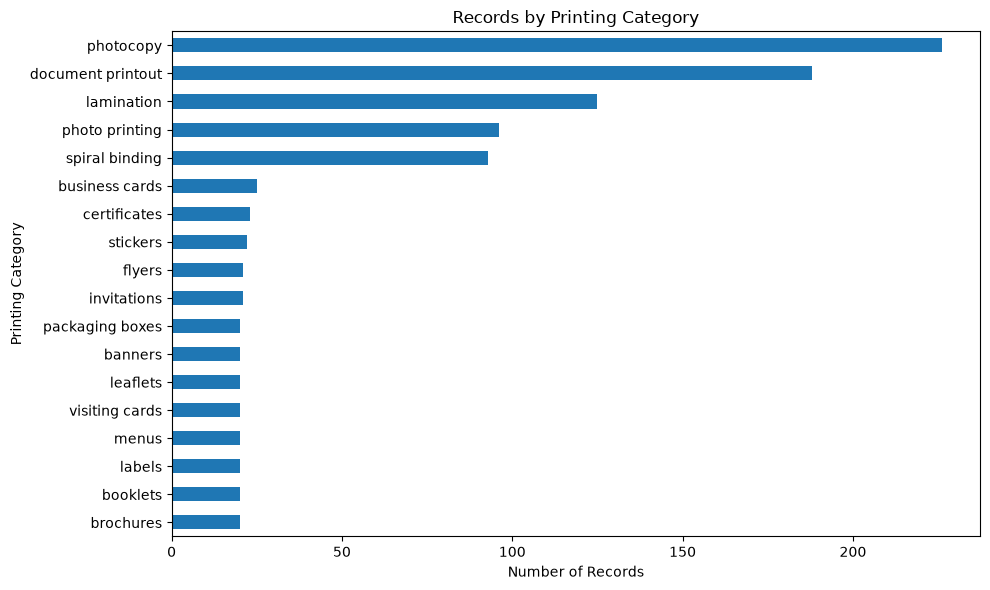

In [6]:
category_counts = price_dataset["print_category"].value_counts()
display(category_counts.to_frame("Record Count"))

plt.figure(figsize=(10, 6))
category_counts.sort_values().plot(kind="barh")
plt.title("Records by Printing Category")
plt.xlabel("Number of Records")
plt.ylabel("Printing Category")
plt.tight_layout()
plt.show()

## EDA 6 - Quantity vs Total Price

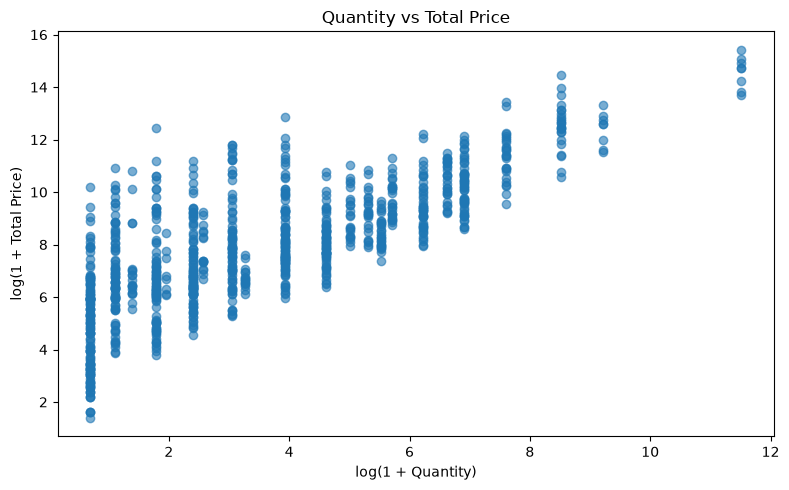

Correlation between quantity and total price: 0.8443


In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    np.log1p(price_dataset["quantity"]),
    np.log1p(price_dataset["total_price"]),
    alpha=0.6
)
plt.title("Quantity vs Total Price")
plt.xlabel("log(1 + Quantity)")
plt.ylabel("log(1 + Total Price)")
plt.tight_layout()
plt.show()

correlation = price_dataset[["quantity", "total_price"]].corr().iloc[0, 1]
print("Correlation between quantity and total price:", round(correlation, 4))

## EDA 7 - Median Price by Printing Category

,Median Total Price
print_category,
lamination,630.010
spiral binding,787.550
photocopy,1022.955
photo printing,1547.540
document printout,3252.660
visiting cards,8559.805
labels,9224.025
stickers,9257.815
business cards,9338.320


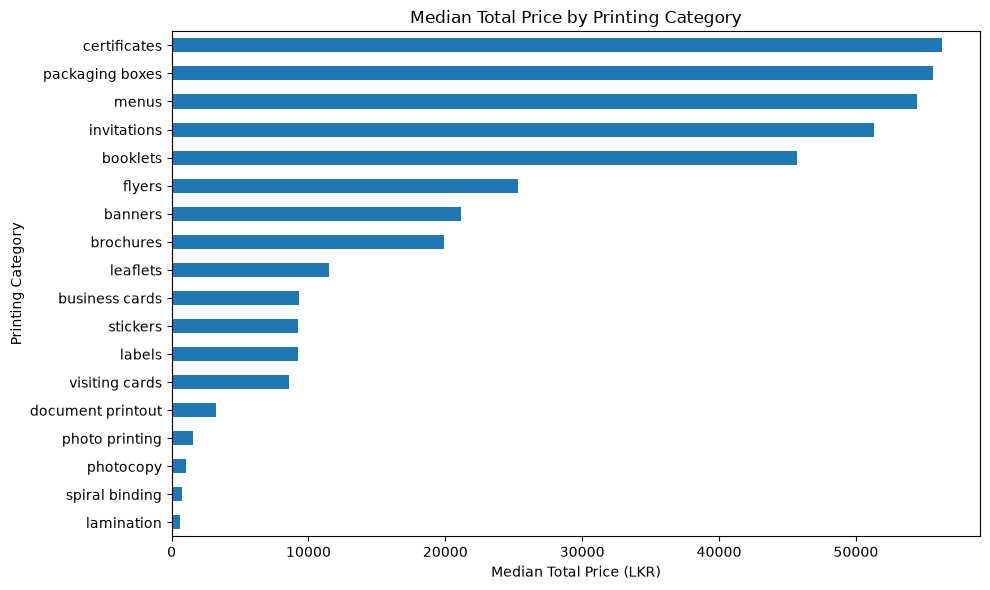

In [8]:
median_price = (
    price_dataset.groupby("print_category")["total_price"]
    .median()
    .sort_values()
)

display(median_price.to_frame("Median Total Price"))

plt.figure(figsize=(10, 6))
median_price.plot(kind="barh")
plt.title("Median Total Price by Printing Category")
plt.xlabel("Median Total Price (LKR)")
plt.ylabel("Printing Category")
plt.tight_layout()
plt.show()

## EDA 8 - Numerical Feature Correlation

,quantity,width,height,gsm,page_count,total_price
quantity,1.000,-0.200,-0.108,-0.037,-0.059,0.844
width,-0.200,1.000,0.987,NaN,NaN,0.688
height,-0.108,0.987,1.000,NaN,NaN,0.779
gsm,-0.037,NaN,NaN,1.000,-0.236,0.029
page_count,-0.059,NaN,NaN,-0.236,1.000,-0.038
total_price,0.844,0.688,0.779,0.029,-0.038,1.000


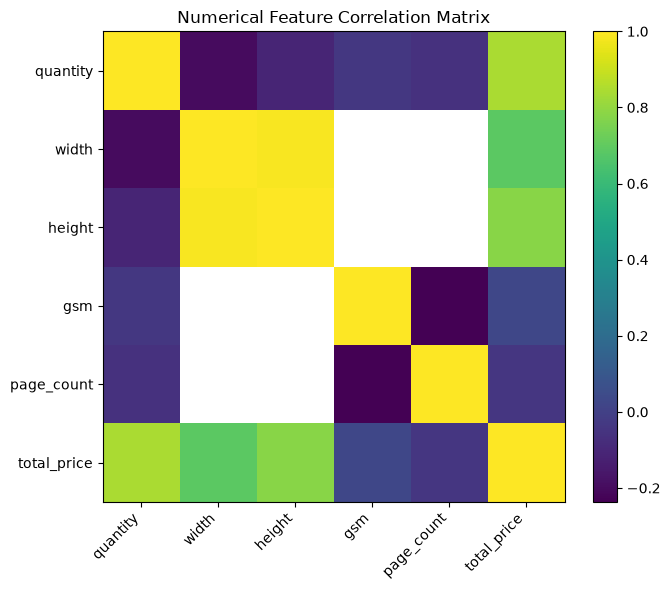

In [9]:
numeric_columns = [
    "quantity", "width", "height", "gsm",
    "page_count", "total_price"
]

corr = price_dataset[numeric_columns].corr()

display(corr.round(3))

plt.figure(figsize=(7, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Data Preparation

In [10]:
# Features that can reasonably be known before a final price is predicted.
# Direct component-cost columns are excluded to prevent target leakage.

feature_columns = [
    "print_category",
    "quantity",
    "standard_size",
    "width",
    "height",
    "paper_type",
    "gsm",
    "colour_mode",
    "sides",
    "page_count",
    "finishing_type",
    "urgency",
    "delivery_requirement",
    "location"
]

target_column = "total_price"

X = price_dataset[feature_columns].copy()
y = price_dataset[target_column].copy()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Target:", target_column)
print("Number of input features:", len(feature_columns))
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

Target: total_price
Number of input features: 14
Categorical features: ['print_category', 'standard_size', 'paper_type', 'colour_mode', 'sides', 'finishing_type', 'urgency', 'delivery_requirement', 'location']
Numerical features: ['quantity', 'width', 'height', 'gsm', 'page_count']


## Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=price_dataset["print_category"]
)

print("Total records used:", len(X_train) + len(X_test))
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Training percentage:", round(len(X_train) / len(X) * 100, 1), "%")
print("Testing percentage:", round(len(X_test) / len(X) * 100, 1), "%")

Total records used: 1000
Training records: 800
Testing records: 200
Training percentage: 80.0 %
Testing percentage: 20.0 %


# Model 1 - Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model = LinearRegression()

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

print("Model 1 - Linear Regression training completed.")

Model 1 - Linear Regression training completed.


## Model Evaluation

In [14]:
predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Value": [mae, rmse, r2]
})

display(results)

print(f"MAE: LKR {mae:,.2f}")
print(f"RMSE: LKR {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"R² Percentage: {r2 * 100:.2f}%")

,Metric,Value
0,MAE,31351.234881
1,RMSE,56201.948440
2,R² Score,0.574364


MAE: LKR 31,351.23
RMSE: LKR 56,201.95
R² Score: 0.5744
R² Percentage: 57.44%


## Actual Price vs Predicted Price

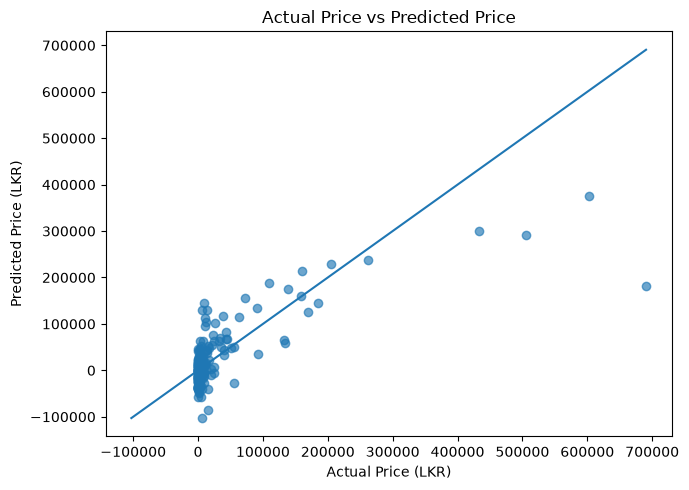

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions, alpha=0.65)

minimum = min(y_test.min(), predictions.min())
maximum = max(y_test.max(), predictions.max())
plt.plot([minimum, maximum], [minimum, maximum])

plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price (LKR)")
plt.ylabel("Predicted Price (LKR)")
plt.tight_layout()
plt.show()

## Prediction Errors

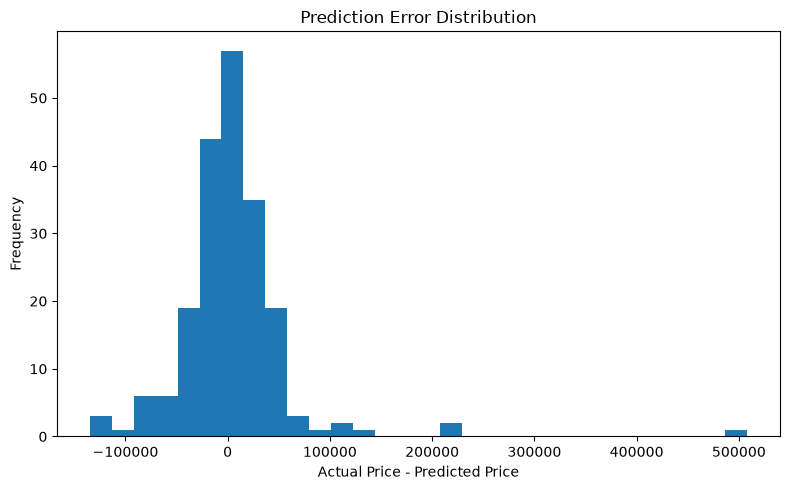

Mean prediction error: 4465.28


In [16]:
residuals = y_test.to_numpy() - predictions

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Actual Price - Predicted Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Mean prediction error:", round(residuals.mean(), 2))

## Linear Regression Coefficient Check

In [17]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
display(
    coef_df.sort_values("Absolute Coefficient", ascending=False)
    .head(15)
    .drop(columns="Absolute Coefficient")
)

,Feature,Coefficient
0,numeric__quantity,250788.572750
16,categorical__print_category_menus,115499.827195
6,categorical__print_category_booklets,97494.014118
15,categorical__print_category_leaflets,-78324.367965
5,categorical__print_category_banners,67149.238347
42,categorical__paper_type_ivory board,66798.774015
64,categorical__finishing_type_spot UV,64373.147651
22,categorical__print_category_visiting cards,-59867.001283
40,categorical__paper_type_copy paper,-58110.028038
39,categorical__paper_type_colour paper,-57721.633083


## Save Trained Model

In [18]:
MODEL_PATH = "../models/linear_regression_price_model.joblib"
os.makedirs("../models", exist_ok=True)

joblib.dump(pipeline, MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: ../models/linear_regression_price_model.joblib


## Conclusion

The model was trained using **800 records** and evaluated using **200 unseen records** from the same 1,000-record dataset.

MAE, RMSE and R² are used to evaluate price prediction performance. The same 80/20 split and preprocessing approach can be used to compare this model fairly with the other two regression models.